In [15]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch_geometric.datasets import EllipticBitcoinDataset
from torch_geometric.utils import to_networkx  # Asegúrate de importar to_networkx
%matplotlib inline

In [7]:
# Instalar PyTorch Geometric
!pip install torch torchvision torchaudio
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install torch-geometric


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 49.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.7 MB/s eta 0:00:00


In [17]:
from torch_geometric.datasets import DeezerEurope

# Directorio donde se guardará el dataset
dataset_path = './data/DeezerEurope'

# Cargar el dataset
dataset = DeezerEurope(root=dataset_path)

# Acceder al primer grafo del dataset
data = dataset[0]

print(data)


Data(x=[28281, 128], edge_index=[2, 185504], y=[28281])


Processing...
Done!


In [18]:
print("Número de nodos:", data.num_nodes)
print("Número de aristas:", data.num_edges)
print("Atributos de nodos:", data.x)
print("Etiquetas:", data.y)


Número de nodos: 28281
Número de aristas: 185504
Atributos de nodos: tensor([[-0.2231, -0.1776, -0.1713,  ..., -0.2608, -0.3070,  0.3880],
        [-0.2231,  0.1626,  0.2821,  ..., -0.2608, -0.2337, -0.0955],
        [-0.2231, -0.1776,  5.0181,  ..., -0.2608, -0.3070, -0.0955],
        ...,
        [-0.2231, -0.1776, -0.1713,  ..., -0.2608, -0.3070, -0.0955],
        [-0.2231, -0.1776, -0.1713,  ..., -0.1293, -0.2427, -0.0955],
        [-0.2231, -0.1361, -0.1556,  ..., -0.2608, -0.3070, -0.0955]])
Etiquetas: tensor([0, 0, 0,  ..., 0, 1, 1])


In [21]:
# Acceder a las features de todos los nodos
node_features = data.x

# Ver todas las features del primer nodo
print("Features del primer nodo:", node_features[0])

# También puedes ver las dimensiones de las features
print("Dimensiones de las features (nodos x características):", node_features.shape)


Features del primer nodo: tensor([-0.2231, -0.1776, -0.1713, -0.2358, -0.2845, -0.2306, -0.1045, -0.1622,
        -0.2499, -0.1942, -0.2930, -0.3135, -0.2304, -0.2104, -0.2717, -0.1618,
        -0.2831, -0.1753, -0.2698, -0.3308, -0.0301, -0.2505, -0.1414, -0.2307,
        -0.1881, -0.2917, -0.0285, -0.0309, -0.3196, -0.1795, -0.2118, -0.2536,
        -0.3220, -0.2838, -0.3155, -0.2465, -0.0624, -0.2904, -0.2627, -0.3150,
        -0.0497, -0.2389, -0.1537, -0.1239, -0.0772, -0.2715, -0.1155, -0.2484,
        -0.0638, -0.2790, -0.2728, -0.2059, -0.2907, -0.0349, -0.2600, -0.2942,
        -0.2757, -0.2625, -0.3712, -0.1056, -0.1000, -0.2394,  3.7313, -0.2853,
        -0.2868, -0.3708, -0.2434, -0.3040, -0.2261, -0.0218, 12.4039, -0.3654,
        -0.1827, -0.4465, -0.3023, -0.2669,  4.3738,  2.6410, -0.2442, -0.0479,
        -0.2852, -0.2217, -0.1578, -0.0217, -0.2984, -0.3206, -0.0274, -0.3182,
        -0.3071, -0.2375, -0.2309, -0.1892, -0.3230, -0.2510, -0.2317, -0.2390,
        -0.392

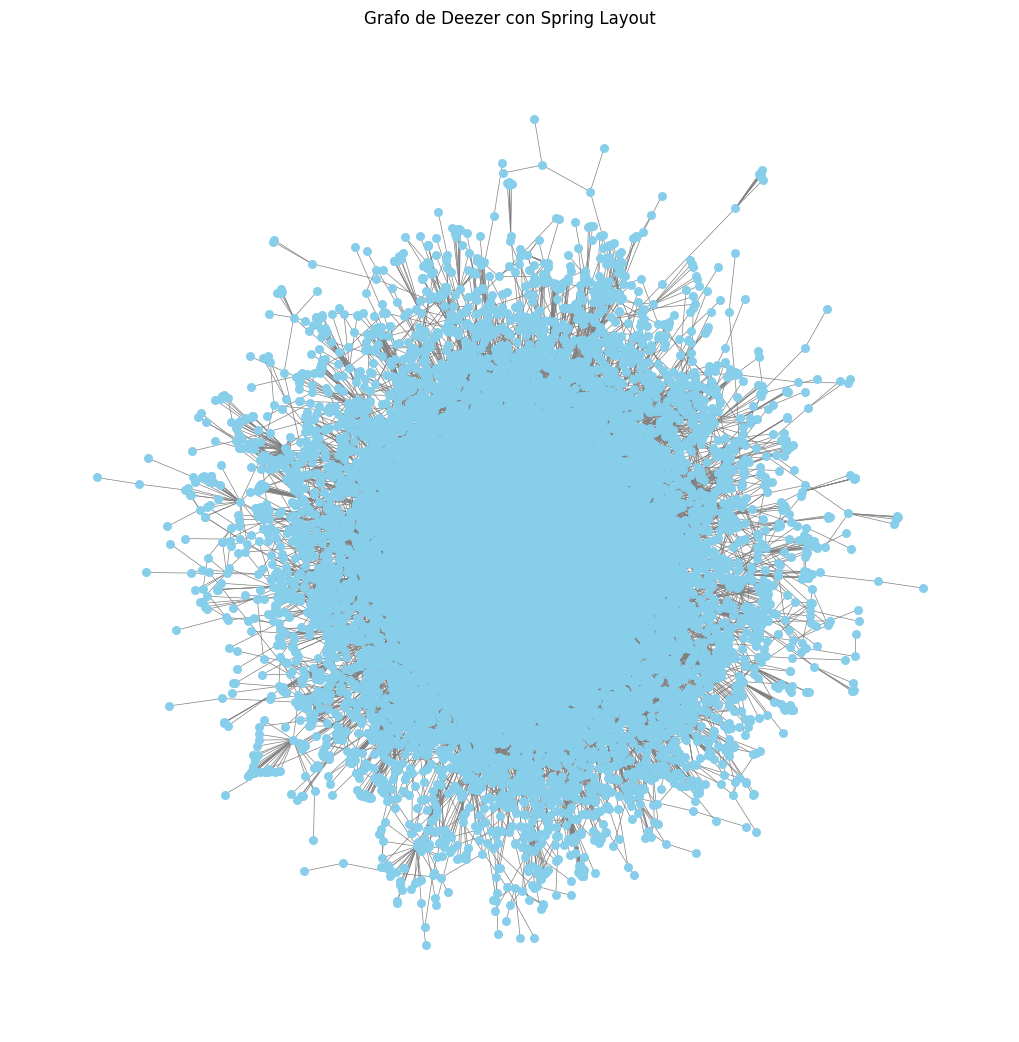

In [23]:
data = dataset[0]

# Convertir el grafo a un objeto de NetworkX
G = to_networkx(data, to_undirected=True)

# Dibuja el grafo usando spring layout
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, iterations=15,seed=42)  # Seed para una disposición consistente
nx.draw(G, pos, with_labels=False, node_size=30, node_color="skyblue", edge_color="gray", width=0.5)
plt.title("Grafo de Deezer con Spring Layout")
plt.show()